In [2]:
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import glob
import os.path as op
import os
from os.path import join, exists
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
import nibabel as nib
import matplotlib.pyplot as plt

In [26]:
## Set variables

# TO CHANGE EVERY TIME
sub_uid = 'sub-004'

# toggle whether to look at all subregions of the fROI or just the overall languege network
# rois = {1:'LH_IFGorb', 2:'LH_IFG', 3:'LH_MFG', 4:'LH_AntTemp', 5:'LH_PostTemp', 6:'LH_AnG', 7:'RH_IFGorb', 8:'RH_IFG', 9:'RH_MFG', 10:'RH_AntTemp', 11:'RH_PostTemp', 12:'RH_AnG', 13: 'ALL'}
rois = {1: 'ALL'}

n_stimuli = 24

In [27]:
## Set paths

# change if running elsewhere 
path_to_parent_directory = '/Users/bianca/Desktop/NEU502B/neu502b_fmri'

path_to_stimsets = f'{path_to_parent_directory}/emotion_word_glmsingle/emotion_word_stim'

path_to_design_matrices = f'{path_to_parent_directory}/emotion_word_glmsingle/design_matrices'

path_to_emotion_word_results = f'{path_to_parent_directory}/emotion_word_glmsingle/output_betas/{sub_uid}/average_item_betas'

path_to_behavioral_data = f'{path_to_parent_directory}/behavioral_task'
behavioral_data_filename = 'behavioral_data.csv'

path_to_export_figs = f'{path_to_parent_directory}/output_figures'


In [28]:
# set up dictionary with correspondence between emotion word ids and words

emotion_word_stim_file = f"{path_to_stimsets}/stimset_emotion_word_{sub_uid}.csv"
emotion_word_stimset = pd.read_csv(emotion_word_stim_file)

emotion_word_dict = {}

# extract word_ids and corresponding words from the emotion word stim file
for i in range(n_stimuli):
    
    # extract word id
    word_id = int(emotion_word_stimset.word_id[i])
    # print(word_id)

    # extract word label
    word_label = emotion_word_stimset.word[i]
    # print(word_label)

    emotion_word_dict[word_id] = word_label


# create new pandas table with just relevant word characteristics 
emotion_word_stim_table = emotion_word_stimset.loc[0:23, ['word_id', 'word', 'category_num', 'category_arousal', 'category_valence']]
emotion_word_stim_table["word_id"] = emotion_word_stim_table["word_id"].astype(int)
emotion_word_stim_table["category_num"] = emotion_word_stim_table["category_num"].astype(int)
# print(emotion_word_stim_table)
# print(len(emotion_word_stim_table))

In [29]:
### extract beta values for each emotion word in each ROI of interest 

# # define affine - no longer needed
# affine = np.array([[2.5, 0., 0., -96.5], 
#                    [0., 2.5, 0., -132.5], 
#                    [0., 0., 2.5, -78.5], 
#                    [0., 0., 0., 1.]])

## extract betas and add them to relevant dicts

emotion_word_betas_dict = {}
emotion_word_betas_lists = {}
# emotion_word_nii_lists = {}

# for each ROI we care about 
for roi_num, roi_label in rois.items():

    emotion_word_betas_dict[roi_label] = {}
    emotion_word_betas_lists[roi_label] = []
    # emotion_word_nii_lists[roi_label] = []

    # set path to fROI-specific directory with npy files with emotion word  
    path_to_emotion_word_betas = f'{path_to_emotion_word_results}/{roi_label}'

    for emotion_word_id, emotion_word_label in emotion_word_dict.items():

        # extract numpy array with beta values for that word
        emotion_word_beta_filename = f'emotion_word_itemID_{emotion_word_id}_{roi_label}_average_item_betas.npy'
        emotion_word_betas = np.load(join(path_to_emotion_word_betas, emotion_word_beta_filename))

        # print(emotion_word_betas.shape)

        emotion_word_betas_flattened = emotion_word_betas.flatten()
        emotion_word_betas_flattened = emotion_word_betas_flattened[np.newaxis, :]
        emotion_word_betas_flattened = np.nan_to_num(emotion_word_betas_flattened)
        # print(emotion_word_betas_flattened.shape)
        # emotion_word_nii = nib.Nifti1Image(emotion_word_betas, affine)
        # print(emotion_word_nii.get_fdata().shape)
        
        # store numpy arrays in the dict of dicts and dict of lists 
        emotion_word_betas_dict[roi_label][word_label] = emotion_word_betas
        emotion_word_betas_lists[roi_label].append(emotion_word_betas_flattened)
        # emotion_word_nii_lists[roi_label].append(emotion_word_nii)


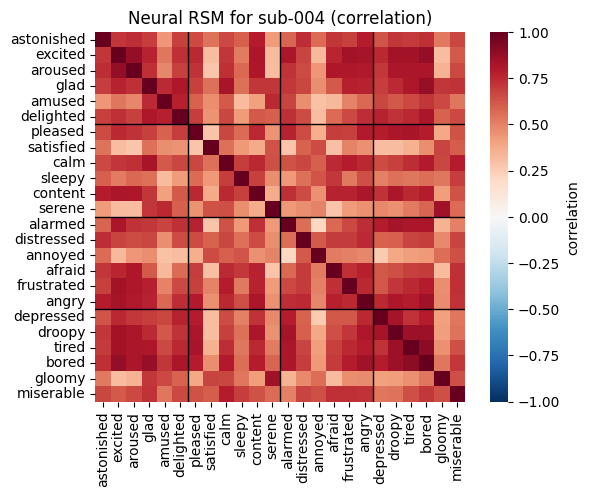

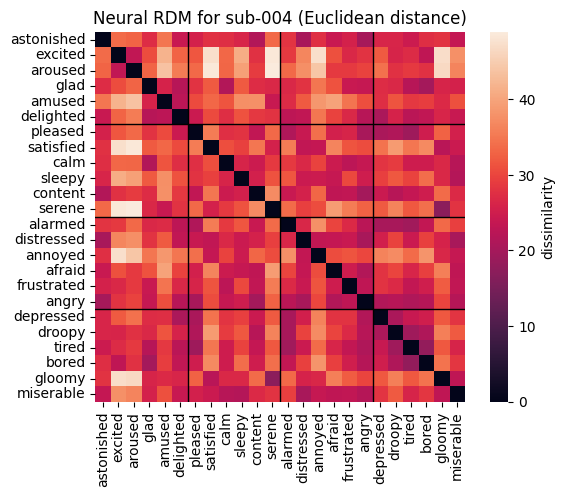

In [30]:
## stack beta arrays and create neural rdms for each ROI

neural_rdm_corr_dict = {}
neural_rdm_euclidean_dict = {}

# for each ROI 
for roi_label, emotion_word_betas_list in emotion_word_betas_lists.items():

    # stack arrays for each word into a single master array 
    stacked_betas = np.vstack(emotion_word_betas_list)
    
    # compute rdm with correlation metric
    rdm_corr = pdist(stacked_betas, metric='correlation')
    neural_rdm_corr_dict[roi_label] = rdm_corr
    
    # compute rdm with euclidean distance metric
    rdm_euclidean = pdist(stacked_betas, metric='euclidean')
    neural_rdm_euclidean_dict[roi_label] = rdm_euclidean

    # source word labels
    word_labels = emotion_word_stim_table["word"]
    # print(word_labels)

    # reorder by categories 
    # category 1 (high arousal, high valence)
    # category 4 (low arousal, high valuence)
    # category 2 (high arousal, low valence)
    # category 3 (low arousal, low valence)
    reorder = [6, 15, 17, 18, 20, 21,   # high arousal, high valence
               2, 5, 8, 9, 11, 19,      # low arousal, high valence
               1, 3, 4, 7, 10, 12,      # high arousal, low valence
               0, 13, 14, 16, 22, 23]   # low arousal, low valence
    
    # print(word_labels[reorder])

    squareform_rdm_corr = squareform(rdm_corr)
    ax = sns.heatmap(1 - squareform_rdm_corr[reorder][:, reorder],  
            vmin = -1, vmax = 1, 
            cmap = 'RdBu_r',
            square = True, 
            xticklabels = word_labels[reorder],
            yticklabels = word_labels[reorder],
            cbar_kws = {'label': 'correlation'})
    for i in range(6, 24, 6):
        ax.axvline(i, color = 'black', lw = 1)
        ax.axhline(i, color = 'black', lw = 1)
    plt.title(f"Neural RSM for {sub_uid} (correlation)")
    plt.savefig(f'{path_to_export_figs}/neural_rdms/{sub_uid}_{roi_label}_neural_rdm_corr.png', 
                bbox_inches='tight')
    plt.show()

    squareform_rdm_euclidean = squareform(rdm_euclidean)
    ax = sns.heatmap(squareform_rdm_euclidean[reorder][:, reorder],  
            # cmap = 'RdBu_r',
            square = True, 
            xticklabels = word_labels[reorder],
            yticklabels = word_labels[reorder],
            cbar_kws = {'label': 'dissimilarity'})
    for i in range(6, 24, 6):
        ax.axvline(i, color = 'black', lw = 1)
        ax.axhline(i, color = 'black', lw = 1)
    plt.title(f"Neural RDM for {sub_uid} (Euclidean distance)")
    plt.savefig(f'{path_to_export_figs}/neural_rdms/{sub_uid}_{roi_label}_neural_rdm_euclidean.png', 
                bbox_inches='tight')
    plt.show()

